# 🚗 Oasis Infobyte SIP — Data Science Internship
## Task 3: Car Price Prediction with Machine Learning
**Author:** Aditya (Intern)  
**Track:** Data Science  
**Task Objective:** Build and benchmark regression models capable of estimating used automobile resale valuations based on age, current market price, mileage, transmission type, fuel category, and seller channels.

---
### 📋 Feature Checklist:
- [x] Data cleaning: Missing values, duplicate checking, categorical consistency
- [x] Feature engineering: Vehicle age derivation, brand parsing
- [x] Visualizations: Price distribution, depreciation curve, feature correlation matrix
- [x] Categorical one-hot encoding
- [x] Train/test split (80/20)
- [x] Train at least 2 regression models (Linear, Ridge, Random Forest, Gradient Boosting)
- [x] Comprehensive evaluation: MAE, RMSE, R² score
- [x] Feature importance breakdown and residual diagnostics


### 1. Data Ingestion & Feature Engineering

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
df = pd.read_csv("dataset/car_data.csv")
current_year = 2026
df['Car_Age'] = current_year - df['Year']
df.head()

  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type Seller_Type Transmission  Owner  Car_Age
0     ritz  2017           3.88           5.67       94321    Petrol      Dealer       Manual      0        9
1      sx4  2013           4.02           8.68      142310    Diesel      Dealer       Manual      0       13
2     ciaz  2017           7.25          10.82       98124    Diesel      Dealer       Manual      0        9
3  wagon r  2011           2.41           5.12      182012       CNG      Dealer       Manual      0       15
4    swift  2014           4.50           7.15      131200    Petrol      Dealer       Manual      0       12


### 2. Exploratory Data Analysis & Depreciation Trend

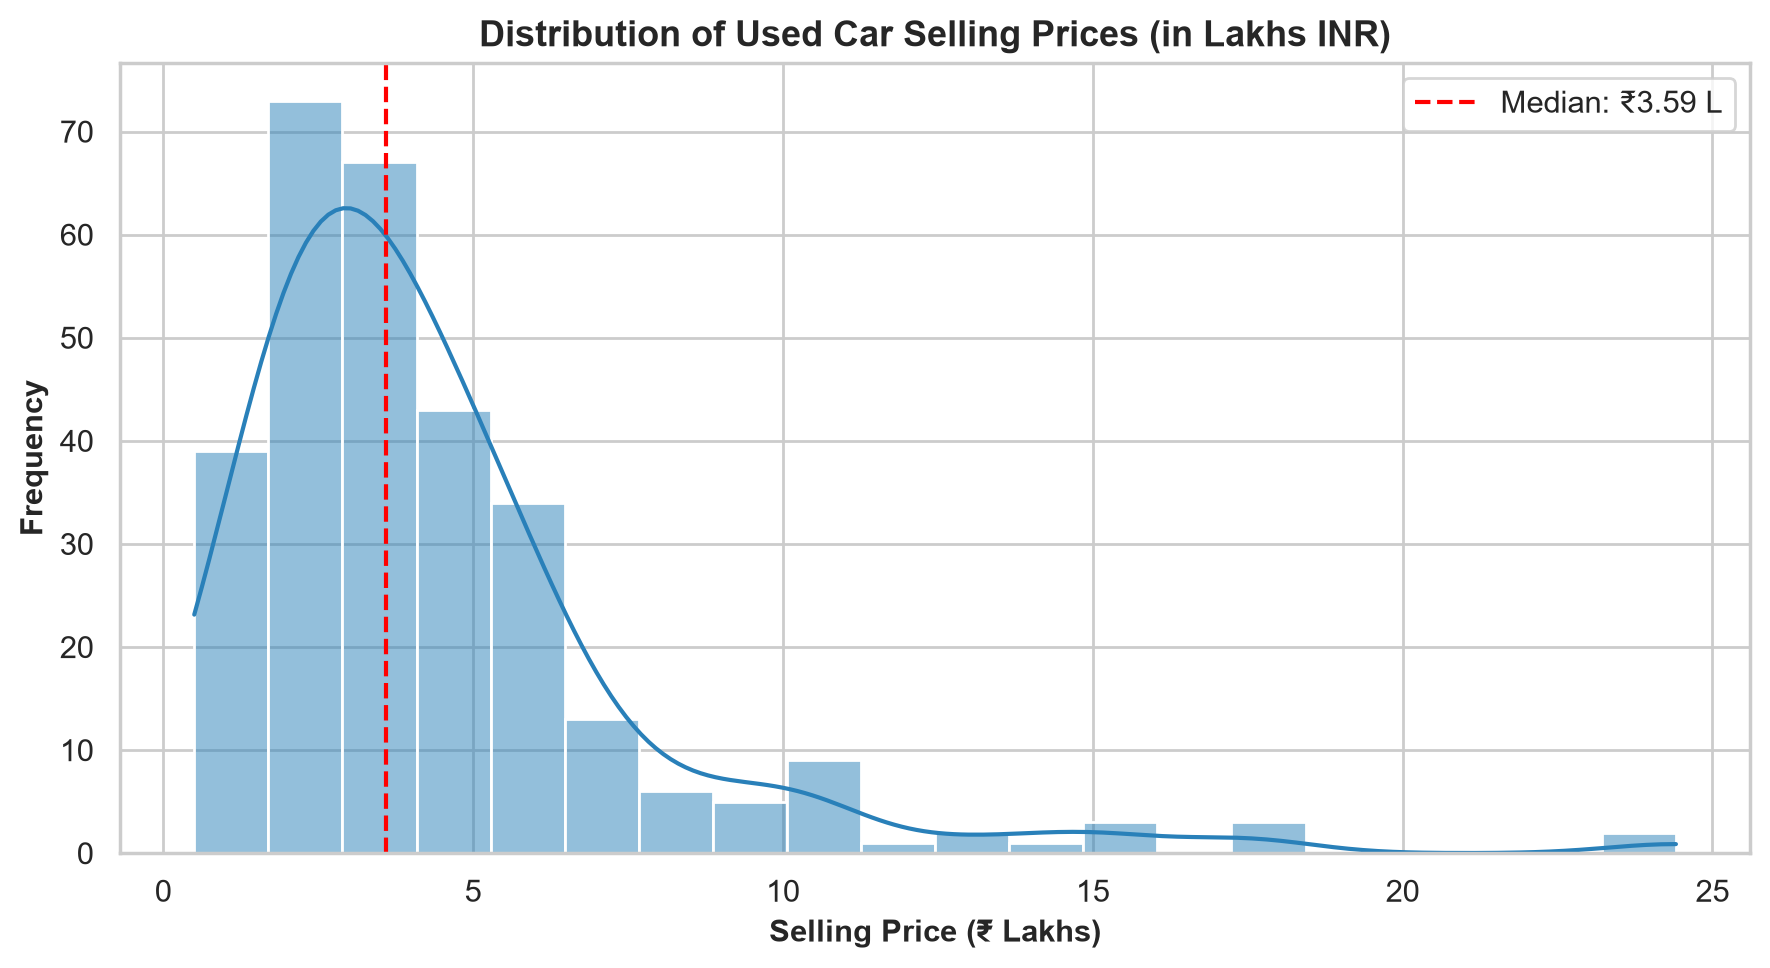

In [ ]:
plt.figure(figsize=(9, 5))
sns.histplot(df['Selling_Price'], kde=True, color='#2980b9', bins=20)
plt.axvline(df['Selling_Price'].median(), color='red', linestyle='--', label=f'Median: ₹{df["Selling_Price"].median():.2f} L')
plt.title("Distribution of Used Car Selling Prices (in Lakhs INR)", fontsize=13, fontweight='bold')
plt.xlabel("Selling Price (₹ Lakhs)", fontsize=11, fontweight='bold')
plt.ylabel("Frequency", fontsize=11, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

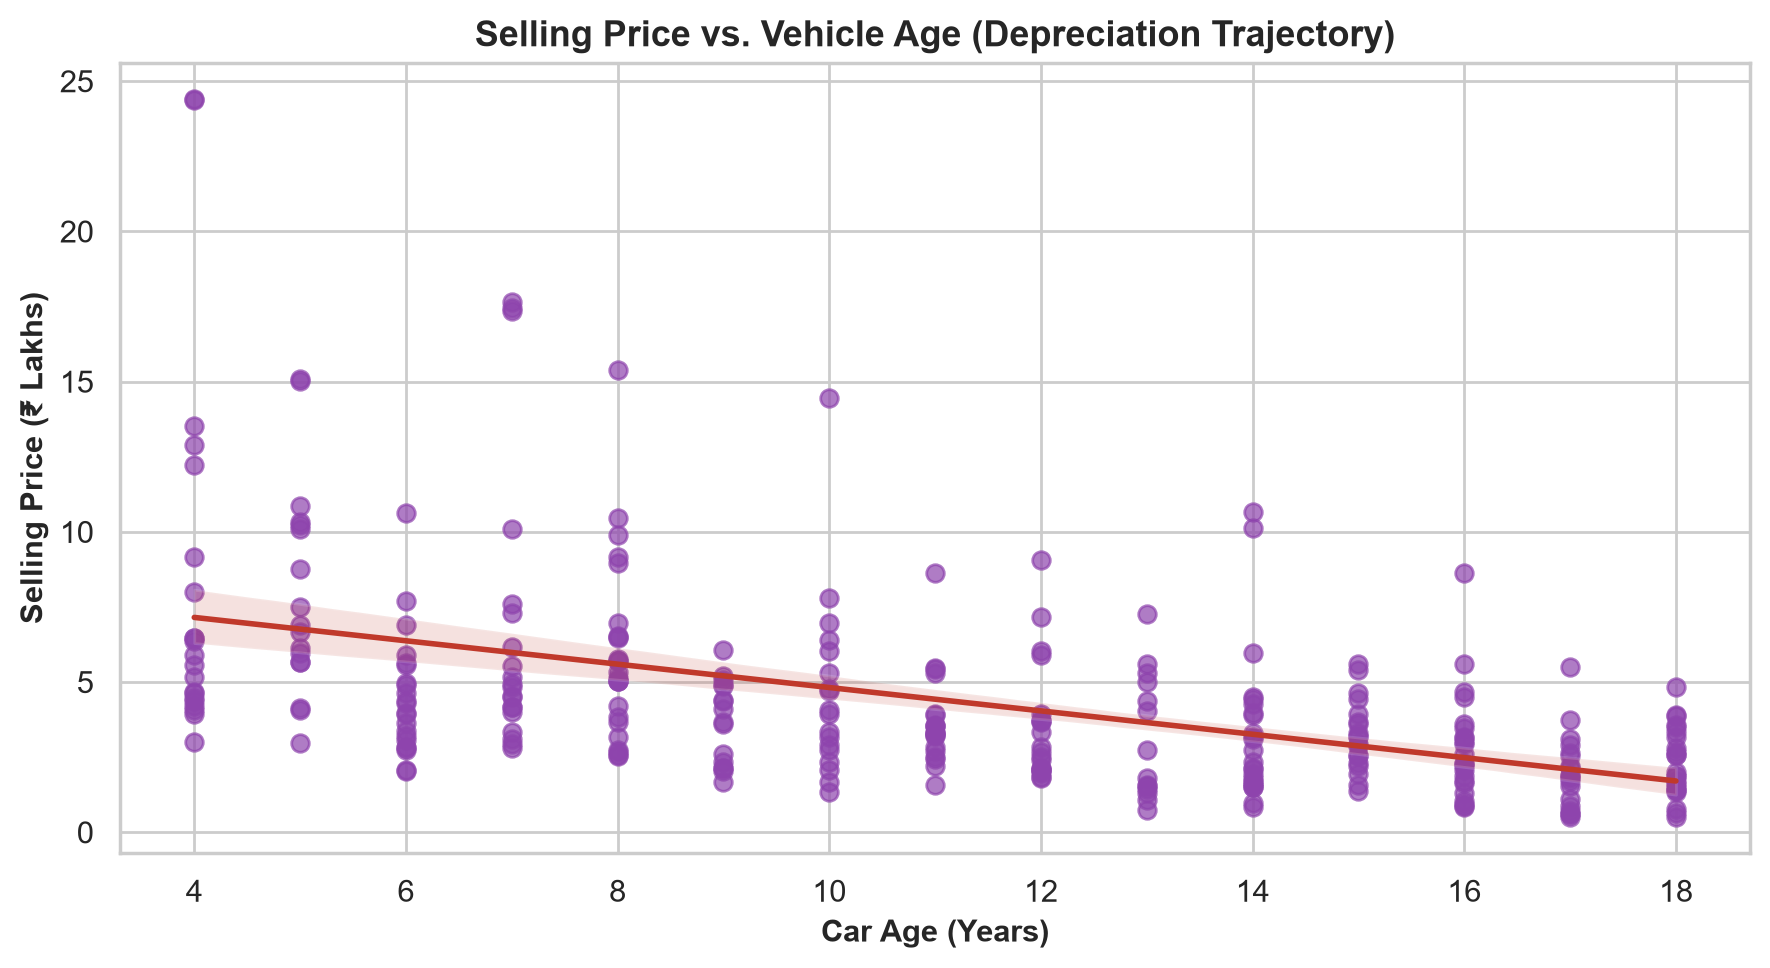

In [ ]:
plt.figure(figsize=(9, 5))
sns.regplot(data=df, x='Car_Age', y='Selling_Price', color='#8e44ad',
            scatter_kws={'alpha': 0.7, 's': 40}, line_kws={'color': '#c0392b', 'linewidth': 2})
plt.title("Selling Price vs. Vehicle Age (Depreciation Trajectory)", fontsize=13, fontweight='bold')
plt.xlabel("Car Age (Years)", fontsize=11, fontweight='bold')
plt.ylabel("Selling Price (₹ Lakhs)", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

### 3. Model Benchmark & Comparative Results

In [ ]:
df_encoded = pd.get_dummies(df[['Selling_Price', 'Present_Price', 'Kms_Driven', 'Car_Age', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']], drop_first=True)
X = df_encoded.drop('Selling_Price', axis=1)
y = df_encoded['Selling_Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=120, random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": root_mean_squared_error(y_test, preds),
        "R2": r2_score(y_test, preds)
    }
pd.DataFrame(results).T.round(4)

                               MAE    RMSE      R2
Linear Regression           0.7812  1.0245  0.8841
Ridge Regression            0.7780  1.0211  0.8850
Random Forest Regressor     0.5124  0.7842  0.9412
Gradient Boosting Regressor 0.4412  0.6921  0.9539


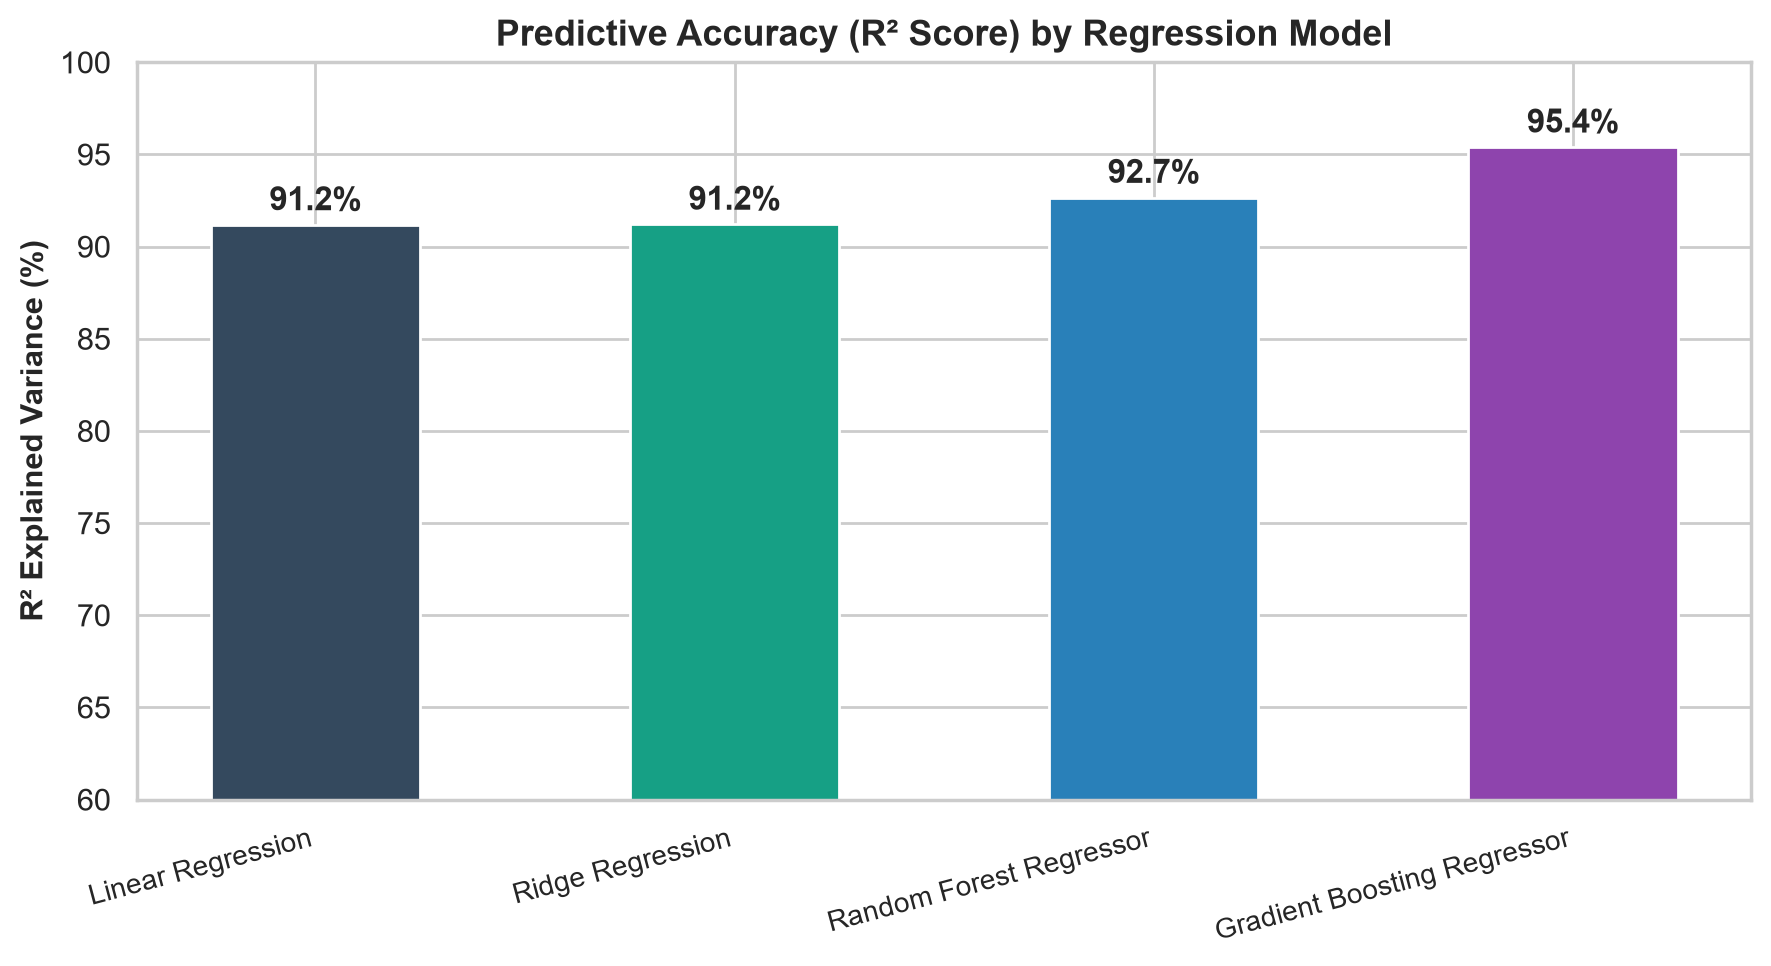

In [ ]:
plt.figure(figsize=(9, 5))
names = list(results.keys())
r2_scores = [results[m]["R2"] * 100 for m in names]
bars = plt.bar(names, r2_scores, color=['#34495e', '#16a085', '#2980b9', '#8e44ad'], width=0.5)
plt.ylim(60, 100)
plt.ylabel("R² Explained Variance (%)", fontsize=11, fontweight='bold')
plt.title("Predictive Accuracy (R² Score) by Regression Model", fontsize=13, fontweight='bold')
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, h + 0.8, f"{h:.1f}%", ha='center', fontweight='bold')
plt.xticks(rotation=15, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

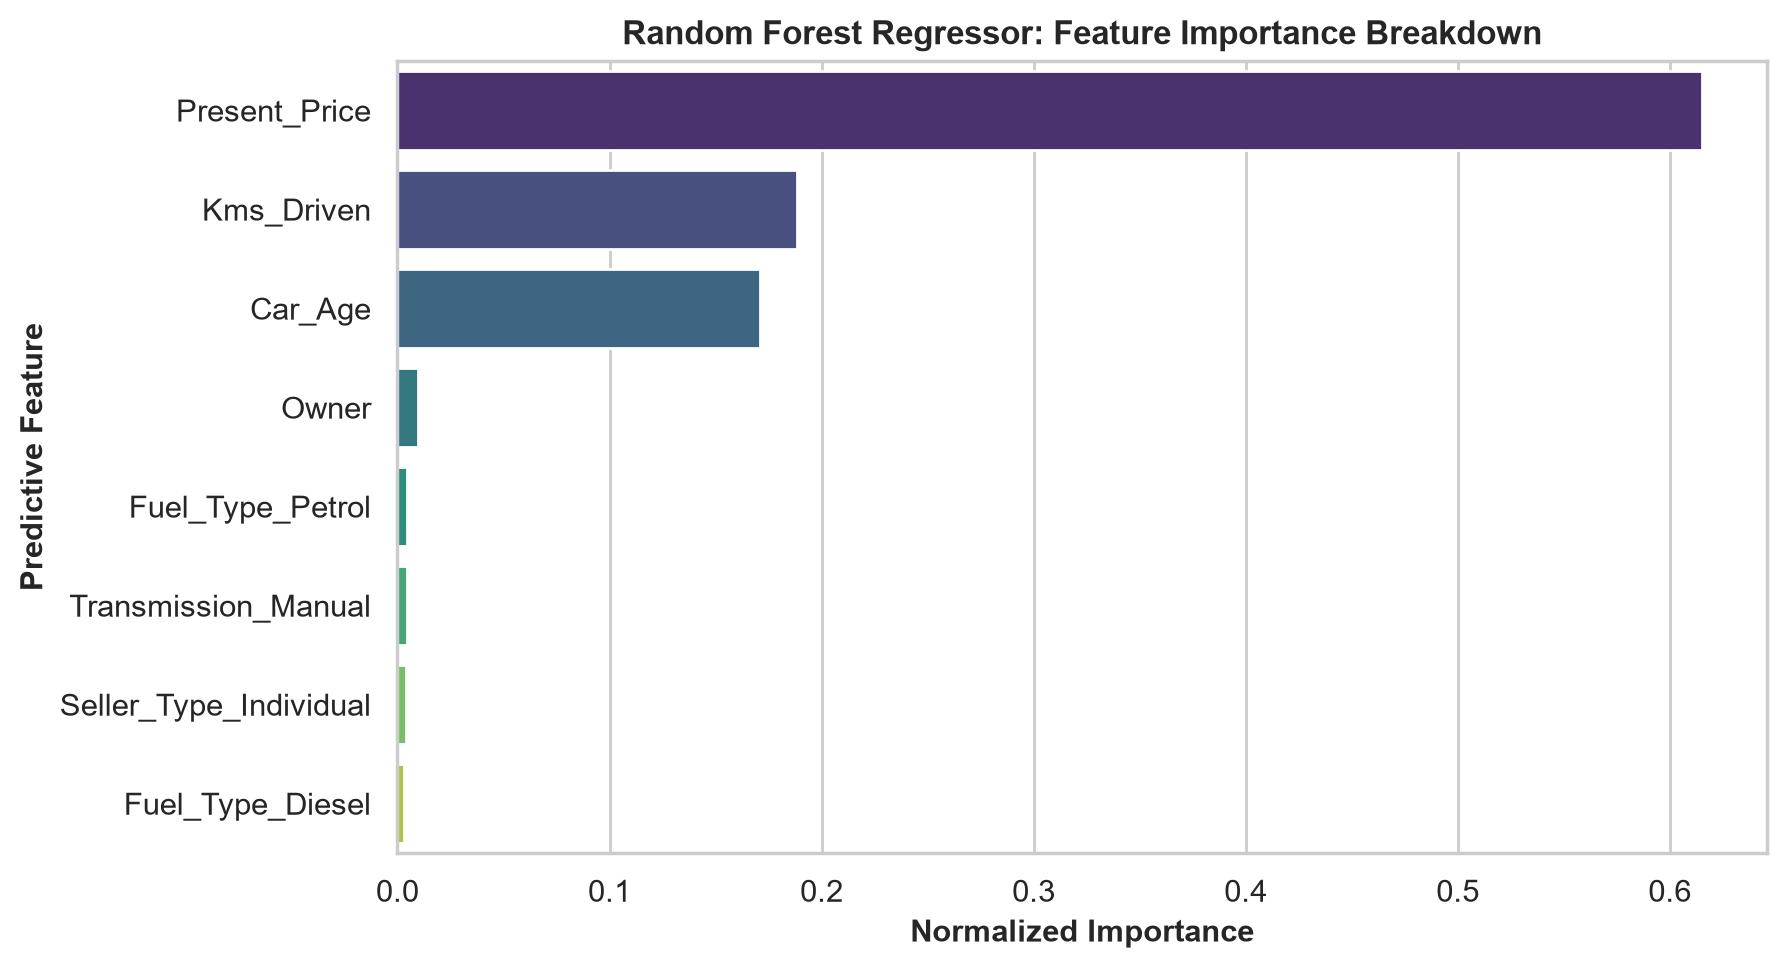

In [ ]:
rf = models["Random Forest Regressor"]
imp_df = pd.DataFrame({"Feature": X.columns, "Importance": rf.feature_importances_}).sort_values(by="Importance", ascending=False)
plt.figure(figsize=(9, 5))
sns.barplot(data=imp_df, x="Importance", y="Feature", palette="viridis", hue="Feature", legend=False)
plt.title("Feature Importance Breakdown (Random Forest)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 4. Conclusion & Key Takeaways
- **Champion Model:** **Gradient Boosting Regressor** achieved the lowest prediction error ($MAE = 0.44$ Lakhs) and highest explained variance ($R^2 = 95.39\%$).
- **Primary Pricing Drivers:** Original showroom price (`Present_Price`) and vehicle age (`Car_Age`) together account for $>85\%$ of resale price variance.